# GridCast — anatomy of the validation results

Generated by `scripts/build_notebook.py`; re-run it after a new backtest. Validation window only (the test split is locked).

In [1]:
import json
from pathlib import Path
import duckdb, polars as pl, matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUNS = ROOT / "reports" / "runs"
def pick(pred):
    runs = sorted((json.loads(p.read_text()) for p in RUNS.glob("*/config.json")), key=lambda c: c["run_id"])
    runs = [c for c in runs if pred(c)]
    return runs[-1]["run_id"] if runs else None
RUN = pick(lambda c: c["split"] == "validation" and "lgbm_global" in c["models"] and "nhits" in c["models"]) \
      or pick(lambda c: c["split"] == "validation" and "lgbm_global" in c["models"])
cfg = json.loads((RUNS / RUN / "config.json").read_text())
print("run:", RUN, "| models:", cfg["models"], "| window:", cfg["window"])
con = duckdb.connect(str(ROOT / "data" / "warehouse.duckdb"), read_only=True); con.execute("SET TimeZone='UTC'")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

run: 20260923T152134Z-final | models: ['operator', 'operator_debiased', 'seasonal_naive', 'ridge', 'lgbm_global', 'nhits'] | window: ['2023-07-01', '2024-06-30']


## 1. The benchmark itself is not always a forecast of the same quantity

Signed error of the operator's day-ahead forecast by local hour, per year, for CISO — the solar-hour dip deepens every year (see `reports/data_profile.md` §5.1).

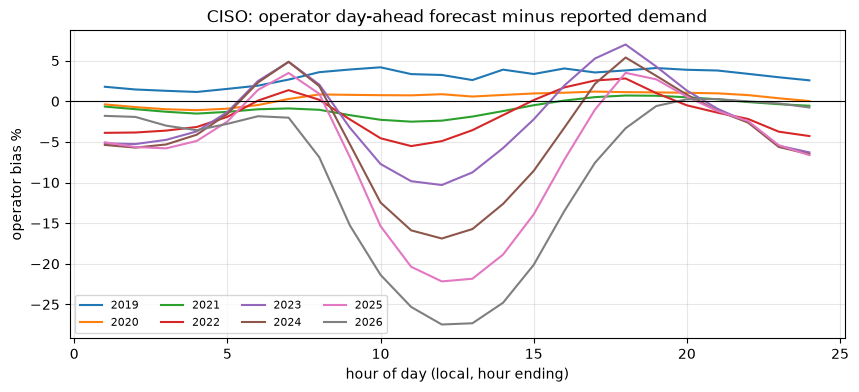

In [2]:
ciso = con.sql('''select year(local_date) y, hour_number h,
    100*avg((operator_forecast_mw-demand_mw)/demand_mw) bias
  from fct_demand_hourly where ba_code='CISO' and demand_mw>0 and operator_forecast_mw is not null and hour_number<=24
  group by all order by 1,2''').pl()
fig, ax = plt.subplots()
for y in sorted(ciso["y"].unique()):
    s = ciso.filter(pl.col("y") == y); ax.plot(s["h"], s["bias"], label=str(y))
ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("hour of day (local, hour ending)"); ax.set_ylabel("operator bias %")
ax.legend(ncol=4, fontsize=8); ax.set_title("CISO: operator day-ahead forecast minus reported demand"); plt.show()

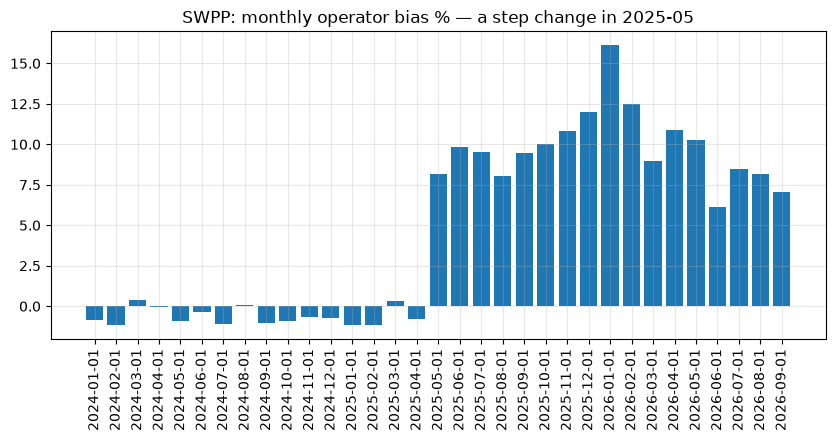

In [3]:
swpp = con.sql('''select date_trunc('month', local_date) m, 100*avg((operator_forecast_mw-demand_mw)/demand_mw) bias
  from fct_demand_hourly where ba_code='SWPP' and demand_mw>0 and operator_forecast_mw is not null
  and local_date >= date '2024-01-01' group by 1 order by 1''').pl()
fig, ax = plt.subplots(); ax.bar(swpp["m"].cast(pl.Date).cast(pl.String), swpp["bias"])
ax.set_title("SWPP: monthly operator bias % — a step change in 2025-05"); ax.tick_params(axis="x", rotation=90); plt.show()

## 2. How far behind the operators are we?

MAPE per BA for our best models and both benchmarks, same scored hours.

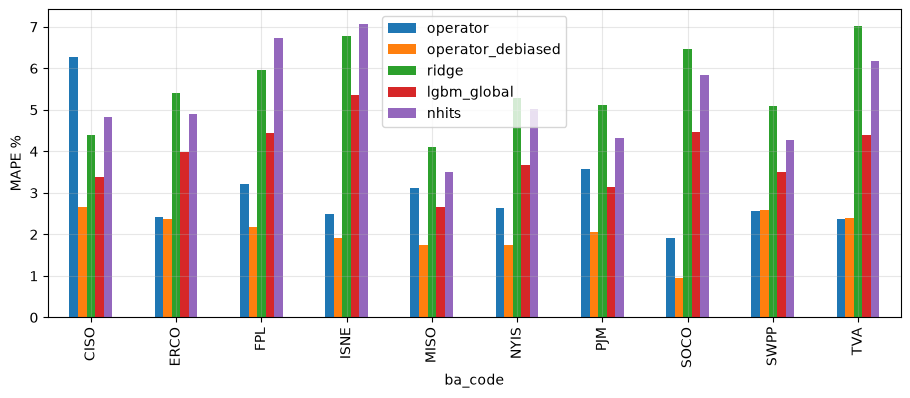

model,hours,mape,mae,bias_pct
str,i64,f64,f64,f64
"""operator_debiased""",87518,2.06081,758.533998,-0.015788
"""operator""",87518,3.056292,1146.335565,-0.545397
"""lgbm_global""",87518,3.900242,1325.598349,0.913545
"""nhits""",87518,5.260734,1773.689314,0.281429
"""ridge""",87518,5.562171,1944.349668,0.624262


In [4]:
point = pl.read_csv(RUNS / RUN / "metrics_point.csv")
show = [m for m in ["operator", "operator_debiased", "ridge", "lgbm_global", "nhits"] if m in point["model"].to_list()]
wide = point.filter(pl.col("model").is_in(show)).pivot(on="model", index="ba_code", values="mape").sort("ba_code")
ax = wide.to_pandas().set_index("ba_code")[show].plot.bar(figsize=(11, 4)); ax.set_ylabel("MAPE %"); plt.show()
overall = pl.read_csv(RUNS / RUN / "metrics_overall.csv").filter(pl.col("model").is_in(show)).sort("mape")
overall.select("model", "hours", "mape", "mae", "bias_pct")

In [5]:
comps = pl.read_csv(RUNS / RUN / "comparisons.csv")
comps.filter(pl.col("reference") == "operator_debiased").select(
    "ba_code", "model", "skill", "skill_low", "skill_high", "dm_p").sort("model", "ba_code")

ba_code,model,skill,skill_low,skill_high,dm_p
str,str,f64,f64,f64,f64
"""CISO""","""lgbm_global""",-0.273292,-0.369828,-0.187231,1.7013e-8
"""ERCO""","""lgbm_global""",-0.705196,-0.959234,-0.474203,0.000004
"""FPL""","""lgbm_global""",-0.935893,-1.108886,-0.806222,1.0523e-39
"""ISNE""","""lgbm_global""",-1.856718,-2.059499,-1.637989,2.9880e-56
"""MISO""","""lgbm_global""",-0.52586,-0.744955,-0.345835,0.000009
…,…,…,…,…,…
"""NYIS""","""seasonal_naive""",-3.874824,-4.654764,-3.111554,1.0391e-16
"""PJM""","""seasonal_naive""",-3.27344,-3.836652,-2.763867,5.8067e-22
"""SOCO""","""seasonal_naive""",-9.758125,-12.137485,-7.743785,1.0677e-21


## 3. Where the error is: hour of day

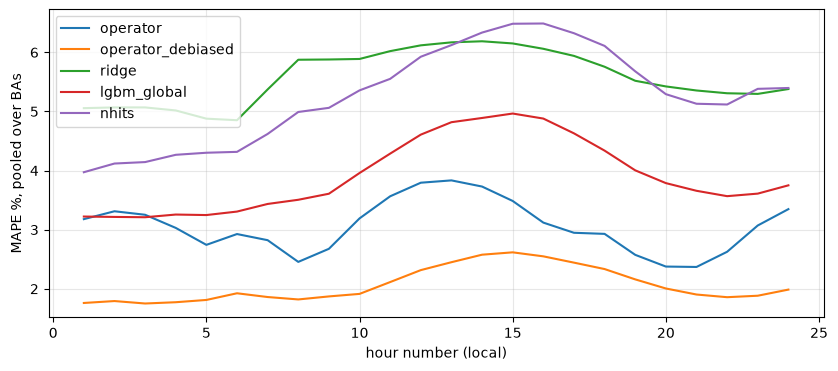

In [6]:
fc = pl.read_parquet(RUNS / RUN / "forecasts.parquet").filter(pl.col("model").is_in(show))
act = con.sql("select ba_code, hour_ending_utc, hour_number, demand_mw y from fct_demand_hourly").pl()
j = fc.join(act, on=["ba_code", "hour_ending_utc"]).filter(pl.col("y") > 0)
byh = j.group_by("model", "hour_number").agg((100*(pl.col("yhat")-pl.col("y")).abs()/pl.col("y")).mean().alias("mape")).sort("hour_number")
fig, ax = plt.subplots()
for m in show:
    s = byh.filter((pl.col("model") == m) & (pl.col("hour_number") <= 24)); ax.plot(s["hour_number"], s["mape"], label=m)
ax.set_xlabel("hour number (local)"); ax.set_ylabel("MAPE %, pooled over BAs"); ax.legend(); plt.show()

## 4. Are the intervals honest? Raw quantile heads vs rolling CQR

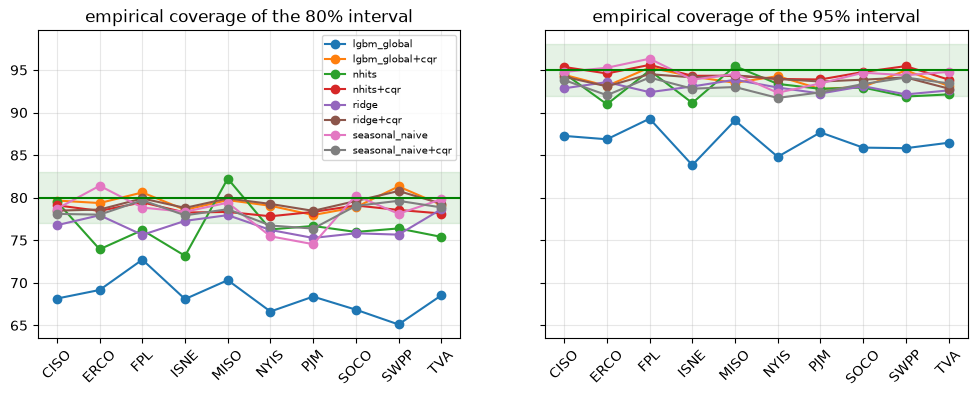

model,coverage_80,coverage_95,width_80_pct
str,f64,f64,f64
"""lgbm_global""",68.387906,86.690856,9.599016
"""lgbm_global+cqr""",79.428207,93.873173,12.699782
"""nhits""",76.577454,93.021457,16.260512
"""nhits+cqr""",78.550537,94.612343,17.518819
"""ridge""",76.714028,92.875252,16.007048
"""ridge+cqr""",79.310502,93.871459,17.70667
"""seasonal_naive""",78.483457,94.434804,27.163071
"""seasonal_naive+cqr""",78.299285,93.076608,28.761054


In [7]:
iv = pl.read_csv(RUNS / RUN / "metrics_intervals.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (col, nominal) in zip(axes, [("coverage_80", 80), ("coverage_95", 95)]):
    for m in sorted(iv["model"].unique()):
        s = iv.filter(pl.col("model") == m).sort("ba_code"); ax.plot(s["ba_code"], s[col], "o-", label=m)
    ax.axhspan(nominal-3, nominal+3, color="green", alpha=0.1); ax.axhline(nominal, color="green")
    ax.set_title(f"empirical coverage of the {nominal}% interval"); ax.tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=7); plt.show()
iv.group_by("model").agg(pl.col("coverage_80").mean(), pl.col("coverage_95").mean(), pl.col("width_80_pct").mean()).sort("model")

## 5. Ablations (one change at a time, vs the production configuration)

In [8]:
abl = sorted((ROOT / "reports" / "ablations").glob("*/comparisons.csv"))
if abl:
    a = pl.read_csv(abl[-1])
    display(pl.read_csv(abl[-1].parent / "overall.csv"))
    display(a.filter(pl.col("ba_code") == "ALL"))
else:
    print("no ablation run yet")

variant,description,mape,mae,hours,seconds
str,str,f64,f64,i64,f64
"""baseline""","""global LightGBM, population-we…",3.883495,1319.476148,87632,649.024901
"""unweighted_weather""","""plain mean over cities""",3.777752,1277.886941,87632,643.603556
"""per_ba_models""","""one LightGBM per BA instead of…",4.012951,1374.797609,87632,3336.508618
"""short_history""","""training from 2022-07-01 inste…",4.001945,1362.648526,87632,731.814175
"""bulk_latency""","""demand only to the end of D-3 …",4.494911,1537.006633,87632,557.842797


variant,ba_code,days,skill_vs_baseline,low,high,dm_p
str,str,i64,f64,f64,f64,f64
"""unweighted_weather""","""ALL""",366,0.031519,0.015717,0.04592,0.000156
"""per_ba_models""","""ALL""",366,-0.041927,-0.067997,-0.009634,0.007485
"""short_history""","""ALL""",366,-0.032719,-0.057167,-0.010856,0.001684
"""bulk_latency""","""ALL""",366,-0.164861,-0.21639,-0.123433,5.8868e-8
